# STEP 3. 공원 필터링과 공원-네트워크 attachment

**목적**: 분석 대상 공원을 정하고, 입구 데이터 없이 각 공원을 네트워크 세그먼트 집합 $B_i$에 연결한다.

**공원 필터 (사용자 결정)**
- 제외: `typecategory` = Flagship Park, 그리고 비공원성 필지(Operations, Lot, Undeveloped, Buildings/Institutions, Cemetery, Managed Sites)
- 면적 상한 100 acres(주 분석). 민감도용으로 50/200도 쓰므로 계산은 200 acres 이하 **상위집합**으로 한다(`in_main` 플래그).

**Attachment 방법 비교**
| 방법 | 내용 | 판단 |
|---|---|---|
| (A) **경계 링 버퍼** | 경계선 ±d m 띠에 **전면(frontage)으로** 닿는 세그먼트(첫 번째 링: 띠 안 길이 ≥ 50% 또는 ≥ 2.5·d). 공원 내부에 90% 이상 들어간 경로는 제외(통행은 허용) | **채택**. 경계 전체가 잠재적 접근 가능하다고 보고, 우연한 최근접 1개에 의존하지 않음 |
| (B) 경계 25 m 샘플점 → 최근접 세그먼트 | 둘레에 비례하는 점 집합 | 비교용. 모서리·짧은 변에서 누락 발생 |
| (C) centroid → 최근접 세그먼트 | 1개 | 기준선. 큰 공원에서 내부 경로를 잡아 위상이 틀어짐 |

- d는 변형마다 다르다: **C = 20 m**(가로 중심선이 도로 폭 절반만큼 떨어져 있음), **S = 10 m**(보도가 경계에 붙어 있음). 민감도는 C {15, 20, 30}, S {5, 10, 20}.
- **크기 효과 통제**: 큰 공원일수록 attachment가 많아 좋은 연결을 얻기 쉽다. 그래서 출발점을 경계 접점 기준 **farthest-point sampling으로 K=8개**(민감도 4)로 제한하고, 연결 강건성은 개수가 아니라 **비율** ρ로 측정한다.
- **unresolved**: attachment가 없거나 모두 작은 연결요소(< 200 세그먼트)에 붙은 공원. OSM 누락 때문일 수 있으므로 "고립"과 구분한다.
- **E0 co-frontage**: attachment 세그먼트를 공유하거나 폴리곤이 맞닿는 공원 쌍. 자명한 연결이라 별도 레이어로 둔다.

- **선형 공원 구간 분할**: Parkway·Strip·Mall이거나 매우 길쭉한(compactness ≥ 20) 공원 중 지름 1 km 이상인 공원을 약 400 m 구간으로 나눠 각각 노드로 쓴다. 수 km 길이의 공원 하나가 멀리 떨어진 공원들을 한 묶음으로 잇는 문제를 막기 위해서다(Brooklyn 파일럿에서 확인).

**출력**(지역 무관, NYC 전체): `Data/derived/network/parks.parquet`, `attachments.parquet`, `pairs_E0.parquet`

In [1]:
# ===== 공통 설정 (모든 STEP 노트북에서 동일) =====
import os
import json
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)

# 분석 지역: "Brooklyn"(파일럿) 또는 "NYC"(전체). 환경변수 PARK_STUDY_AREA로도 지정 가능.
STUDY_AREA = os.environ.get("PARK_STUDY_AREA", "Brooklyn")

ROOT = Path.cwd()
DATA = ROOT / "Data"
PARKS_PATH = DATA / "NYCPark" / "Parks_Properties_20260923.geojson"
NET_DIR = DATA / "derived" / "network"        # STEP1 결과 (지역 무관, NYC+버퍼 전체)
AREA_DIR = DATA / "derived" / STUDY_AREA      # STEP2 이후 결과
OUT_DIR = ROOT / "outputs" / STUDY_AREA
for _d in (NET_DIR, AREA_DIR, OUT_DIR):
    _d.mkdir(parents=True, exist_ok=True)

CRS = 32618            # UTM 18N (m)
R_MAX = 3200           # 탐색 한계 (m) = 보로 네트워크 버퍼 폭
SPEED = 1.0            # speed_m_s=1 -> agg_seconds == 경로 길이(m)

BOROUGHS = {"M": "Manhattan", "X": "Bronx", "B": "Brooklyn", "Q": "Queens", "R": "Staten Island"}
AREA_BOROUGHS = ["B"] if STUDY_AREA == "Brooklyn" else list(BOROUGHS)

# 네트워크 변형: C = 가로 중심선 + 보행전용 경로 (주 분석), S = 보도 포함 전체 보행망 (민감도)
VARIANTS = ["C", "S"]
PRIMARY = "C"
SIDEWALK_FOOTWAYS = {"sidewalk", "crossing", "traffic_island"}

# 공원 필터 (사용자 결정): Flagship + 비공원성 필지 제외, 면적 상한 100 acres (계산은 200 상위집합)
EXCLUDE_TYPES = ["Flagship Park", "Operations", "Lot", "Undeveloped",
                 "Buildings/Institutions", "Cemetery", "Managed Sites"]
AREA_CAP = 100
AREA_CAP_SUPERSET = 200
AREA_CAP_GRID = [50, 100, 200]
RESTRICTED_TYPES = ["Garden", "Jointly Operated Playground"]            # 접근 제한 민감도
STREET_EMBEDDED_TYPES = ["Triangle/Plaza", "Strip", "Mall", "Parkway"]  # 가로 매몰형 민감도

# 공원-네트워크 attachment
ATTACH_BUFFER = {"C": 20.0, "S": 10.0}   # 경계 버퍼 (m): C는 중심선이 도로 폭 절반만큼 떨어져 있음
ATTACH_BUFFER_GRID = {"C": [15.0, 20.0, 30.0], "S": [5.0, 10.0, 20.0]}
INSIDE_SHARE = 0.9       # 공원 내부에 90% 이상 들어간 세그먼트는 attachment에서 제외 (통행은 허용)
K_SOURCES = 8            # 공원당 출발 attachment 최대 개수 (farthest-point sampling)
SMALL_COMPONENT = 200    # 이보다 작은 연결요소에만 붙은 공원은 'unresolved'

# N1 angular few-turn
N1_THETAS = [15, 45, 90, 180]
N1_RADII = [800, 1600, 3200]
N1_REL_Q = [0.1, 0.2]
DIST_BANDS = [0, 200, 400, 800, 1600, 3200]

# N2 configurational corridor
N2_RADII = [800, 1600, 3200]
N2_TOP_P = [0.02, 0.05, 0.10]
STROKE_ANGLE = 30
STROKE_ANGLE_GRID = [20, 30, 45]
N2_MAX_ALONG = [3200, None]

# N3 excess few-turn field overlap
N3_THETAS = [45, 90]
N3_RADII = [800, 1600]
N3_TAU = [0.1, 0.2]
N3_KAPPA = [1.0, 1.25]

print(f"STUDY_AREA={STUDY_AREA}  boroughs={AREA_BOROUGHS}  AREA_DIR={AREA_DIR.relative_to(ROOT)}")

STUDY_AREA=NYC  boroughs=['M', 'X', 'B', 'Q', 'R']  AREA_DIR=Data/derived/NYC


In [2]:
import shapely
import matplotlib.pyplot as plt

boroughs = gpd.read_file(NET_DIR / "boundaries.gpkg", layer="boroughs").set_index("borough")

## 3-1. 공원 필터

In [3]:
raw = gpd.read_file(PARKS_PATH).to_crs(CRS)
raw["acres"] = raw["acres"].astype(float)
print("raw parks:", len(raw))
print("excluded by type:", raw["typecategory"].isin(EXCLUDE_TYPES).sum(),
      raw.loc[raw["typecategory"].isin(EXCLUDE_TYPES), "typecategory"].value_counts().to_dict())

parks = raw[~raw["typecategory"].isin(EXCLUDE_TYPES) & (raw["acres"] <= AREA_CAP_SUPERSET)].copy()
assert parks["gispropnum"].is_unique
parks = parks.rename(columns={"gispropnum": "park_id", "signname": "name"})
parks["geometry"] = parks.geometry.make_valid()
parks["in_main"] = parks["acres"] <= AREA_CAP
parks["perimeter_m"] = parks.geometry.boundary.length
parks["n_parts"] = parks.geometry.apply(lambda g: len(getattr(g, "geoms", [g])))
parks["restricted"] = parks["typecategory"].isin(RESTRICTED_TYPES)
parks["street_embedded"] = parks["typecategory"].isin(STREET_EMBEDDED_TYPES)
parks = parks[["park_id", "name", "typecategory", "subcategory", "borough", "acres", "perimeter_m", "n_parts",
               "in_main", "restricted", "street_embedded", "geometry"]].set_index("park_id", drop=False)
print(f"superset (≤{AREA_CAP_SUPERSET} ac): {len(parks):,}   main (≤{AREA_CAP} ac): {parks.in_main.sum():,}")
parks[parks.in_main].groupby("borough").size().rename("main parks")

raw parks: 2061
excluded by type: 107 {'Undeveloped': 38, 'Buildings/Institutions': 20, 'Managed Sites': 15, 'Flagship Park': 15, 'Cemetery': 12, 'Lot': 5, 'Operations': 2}
superset (≤200 ac): 1,929   main (≤100 ac): 1,902


borough
B    599
M    380
Q    433
R    124
X    366
Name: main parks, dtype: int64

## 3-2. Attachment (경계 링 버퍼, 첫 번째 링)

In [4]:
def attach(parks, segs, d, inside_share=INSIDE_SHARE, erode=5.0, frontage_mult=2.5):
    """경계 링 버퍼 attachment.

    - 링(경계 ±d)에 닿는 세그먼트 중
    - 공원 내부(경계에서 5 m 안쪽)에 90% 이상 들어간 내부 경로는 제외
    - **전면(frontage) 조건**: 링 안에 들어간 길이가 세그먼트 길이의 50% 이상이거나 min(2.5·d, 둘레의 25%) 이상
      → 모서리에서 링을 스치기만 하는 직교 가로(공원에서 멀어지는 세그먼트)를 제외
      (작은 삼각지·광장은 둘레 기준으로 완화, 그래도 없으면 링에 닿는 비내부 세그먼트 전부 사용)
    - 접점(contact) = 링 안 부분의 중심 → FPS 샘플링에 사용
    """
    boundary = np.asarray(parks.geometry.boundary.values)
    ring = shapely.buffer(boundary, d)
    p_idx, s_idx = segs.sindex.query(ring, predicate="intersects")
    seg_geoms = np.asarray(segs.geometry.values)[s_idx]
    seg_len = shapely.length(seg_geoms)
    inner = shapely.buffer(np.asarray(parks.geometry.values), -erode)
    inside_len = shapely.length(shapely.intersection(seg_geoms, inner[p_idx]))
    share_inside = np.where(seg_len > 0, inside_len / seg_len, 0)
    in_ring = shapely.intersection(seg_geoms, ring[p_idx])
    ring_len = shapely.length(in_ring)
    perim = shapely.length(boundary)[p_idx]
    frontage = (ring_len >= 0.5 * seg_len) | (ring_len >= np.minimum(frontage_mult * d, 0.25 * perim))
    not_inner = share_inside < inside_share
    keep = not_inner & frontage
    has_any = pd.Series(keep).groupby(p_idx).transform("any").values
    keep = keep | (not_inner & ~has_any)       # fallback: 전면 조건을 만족하는 세그먼트가 없는 공원
    contact = shapely.centroid(in_ring[keep])
    out = pd.DataFrame({
        "park_id": parks.index.values[p_idx[keep]],
        "seg_id": segs["seg_id"].values[s_idx[keep]],
        "seg_len": seg_len[keep],
        "ring_len": ring_len[keep],
        "dist_boundary": shapely.distance(seg_geoms[keep], boundary[p_idx[keep]]),
        "comp_size": segs["comp_size"].values[s_idx[keep]],
        "kind": segs["kind"].values[s_idx[keep]],
        "sep_sidewalk": segs["sep_sidewalk"].values[s_idx[keep]],
        "mx": shapely.get_x(contact),
        "my": shapely.get_y(contact),
    })
    return out


def fps_rank(df, parks):
    """Farthest-point sampling order of attachment contact points within each park.

    rank 0 = 경계에서 가장 긴 전면(ring_len 최대)을 가진 attachment, 이후 기존 선택점에서 가장 먼 접점 순.
    """
    ranks = np.empty(len(df), dtype=np.int32)
    for pid, g in df.groupby("park_id").indices.items():
        xy = df[["mx", "my"]].values[g]
        order = [int(np.argmax(df["ring_len"].values[g]))]
        dmin = ((xy - xy[order[0]]) ** 2).sum(1)
        for _ in range(len(g) - 1):
            nxt = int(np.argmax(dmin))
            order.append(nxt)
            dmin = np.minimum(dmin, ((xy - xy[nxt]) ** 2).sum(1))
        r = np.empty(len(g), dtype=np.int32)
        r[order] = np.arange(len(g))
        ranks[g] = r
    return ranks


att_all = []
for v in VARIANTS:
    segs = gpd.read_parquet(NET_DIR / f"segments_{v}.parquet",
                            columns=["seg_id", "kind", "sep_sidewalk", "comp_size", "geometry"])
    for d in ATTACH_BUFFER_GRID[v]:
        a = attach(parks, segs, d)
        a["variant"], a["d"] = v, d
        a["fps_rank"] = fps_rank(a, parks)
        att_all.append(a)
        n_par = a.park_id.nunique()
        print(f"[{v}] d={d:>4}: {len(a):,} attachments, parks with ≥1: {n_par:,}/{len(parks):,}, "
              f"median per park {a.groupby('park_id').size().median():.0f}")
    del segs
att = pd.concat(att_all, ignore_index=True)
att["is_default"] = att.apply(lambda r: r["d"] == ATTACH_BUFFER[r["variant"]], axis=1)

[C] d=15.0: 30,687 attachments, parks with ≥1: 1,916/1,929, median per park 7


[C] d=20.0: 37,387 attachments, parks with ≥1: 1,918/1,929, median per park 9


[C] d=30.0: 45,362 attachments, parks with ≥1: 1,919/1,929, median per park 12


[S] d= 5.0: 20,095 attachments, parks with ≥1: 1,826/1,929, median per park 5


[S] d=10.0: 37,891 attachments, parks with ≥1: 1,902/1,929, median per park 10


[S] d=20.0: 76,648 attachments, parks with ≥1: 1,918/1,929, median per park 22


## 3-2b. 선형 공원 구간 분할
- 대상: (`typecategory` ∈ {Parkway, Strip, Mall} **또는** compactness $P^2/4\pi A$ ≥ 20) **그리고** 지름(볼록껍질 최대 거리) ≥ 1 km
- 방법: 경계를 20 m 간격으로 샘플링 → k-means(k = ⌈지름 / 400 m⌉) → 중심점 Voronoi 셀로 폴리곤 분할
- attachment는 접점이 가장 가까운 구간에 재배정하고, FPS 순위는 구간 안에서 다시 계산
- 구간 노드: `park_id` = `{원래 id}#{k}`, `parent_id`로 원래 공원 추적. 면적 상한 판정에는 **원래 공원 면적**(`acres`)을 쓰고, 구간 면적은 `piece_acres`에 둔다.
- 같은 공원의 구간끼리는 맞닿아 있어 E0(자명한 연결)으로 분류되므로 묶음 형성에 기여하지 않는다.

In [5]:
from sklearn.cluster import KMeans

LINEAR_TYPES = ["Parkway", "Strip", "Mall"]
SPLIT_MIN_DIAM, SPLIT_PIECE, SPLIT_COMPACT = 1000.0, 400.0, 20.0


def diameter(g):
    hull = np.asarray(g.convex_hull.exterior.coords)
    d2 = ((hull[:, None, :] - hull[None, :, :]) ** 2).sum(-1)
    return float(np.sqrt(d2.max()))


parks["diameter_m"] = parks.geometry.apply(diameter)
parks["compactness"] = parks.perimeter_m ** 2 / (4 * np.pi * parks.area)
split_mask = (parks.diameter_m >= SPLIT_MIN_DIAM) & (parks.typecategory.isin(LINEAR_TYPES) | (parks.compactness >= SPLIT_COMPACT))
parks["parent_id"] = parks.index
parks["piece_acres"] = parks.geometry.area / 4046.86
pieces, centers = [], {}
for pid, row in parks[split_mask].iterrows():
    k = int(np.ceil(row.diameter_m / SPLIT_PIECE))
    bnd = row.geometry.boundary
    pts = shapely.line_interpolate_point(bnd, np.arange(0, bnd.length, 20.0))
    xy = np.c_[shapely.get_x(pts), shapely.get_y(pts)]
    xy0 = xy.mean(0)
    with warnings.catch_warnings(), np.errstate(all="ignore"):   # macOS Accelerate의 허위 matmul 경고 억제
        warnings.simplefilter("ignore", RuntimeWarning)
        km = KMeans(n_clusters=k, n_init=4, random_state=0).fit(xy - xy0)   # 중심화(수치 안정)
    ctr = km.cluster_centers_ + xy0
    cells = shapely.voronoi_polygons(shapely.multipoints(ctr), extend_to=row.geometry.envelope.buffer(500))
    cells = list(cells.geoms)
    order = [int(np.argmin([c.distance(shapely.Point(x, y)) for c in cells])) for x, y in ctr]
    for j, (x, y) in enumerate(ctr):
        piece = row.geometry.intersection(cells[order[j]])
        if piece.is_empty:
            continue
        r = row.copy()
        r["geometry"] = piece
        r["park_id"] = f"{pid}#{j + 1}"
        r["name"] = f"{row['name']} ({j + 1}/{k})"
        r["piece_acres"] = piece.area / 4046.86
        r["perimeter_m"] = piece.boundary.length
        r["n_parts"] = len(getattr(piece, "geoms", [piece]))
        pieces.append(r)
    centers[pid] = ([f"{pid}#{j + 1}" for j in range(k)], ctr)
pieces = gpd.GeoDataFrame(pieces, crs=CRS).set_index("park_id", drop=False)
print(f"split {int(split_mask.sum())} linear parks into {len(pieces)} pieces")
display(parks[split_mask].assign(pieces=[len(centers[p][0]) for p in parks[split_mask].index])
        [["name", "typecategory", "borough", "acres", "diameter_m", "compactness", "pieces"]]
        .sort_values("diameter_m", ascending=False).round(1))

# attachment 재배정: 접점에서 가장 가까운 구간 중심
for pid, (ids, ctr) in centers.items():
    m = att.park_id == pid
    xy = att.loc[m, ["mx", "my"]].values
    nearest = ((xy[:, None, :] - ctr[None, :, :]) ** 2).sum(-1).argmin(1)
    att.loc[m, "park_id"] = np.array(ids)[nearest]
# 네트워크 attachment가 없는 구간(내부만 있는 구간, 떨어진 작은 조각)은 가장 가까운 attachment 있는 구간에 병합
has_att = set(att.loc[(att.variant == PRIMARY) & att.is_default, "park_id"])
merged = 0
for pid, (ids, ctr) in centers.items():
    ids = [i for i in ids if i in pieces.index]
    ok = [i for i in ids if i in has_att]
    if not ok:
        continue
    for i in [i for i in ids if i not in has_att]:
        tgt = min(ok, key=lambda o: pieces.at[o, "geometry"].distance(pieces.at[i, "geometry"]))
        pieces.at[tgt, "geometry"] = pieces.at[tgt, "geometry"].union(pieces.at[i, "geometry"])
        att.loc[att.park_id == i, "park_id"] = tgt
        pieces = pieces.drop(index=i)
        merged += 1
pieces["piece_acres"] = pieces.geometry.area / 4046.86
pieces["perimeter_m"] = pieces.geometry.boundary.length
pieces["n_parts"] = pieces.geometry.apply(lambda g: len(getattr(g, "geoms", [g])))
print(f"merged {merged} attachment-less pieces → {len(pieces)} pieces")
valid = set(pieces.index)
att = att[~att.park_id.str.contains("#") | att.park_id.isin(valid)]
parks = pd.concat([parks[~split_mask], pieces])
parks["is_piece"] = parks.park_id.str.contains("#")
# FPS 순위를 (변형, d, 공원)마다 다시 계산
att["fps_rank"] = 0
for (v, d), idx in att.groupby(["variant", "d"]).groups.items():
    sub = att.loc[idx]
    att.loc[idx, "fps_rank"] = fps_rank(sub.reset_index(drop=True), parks)
att.to_parquet(NET_DIR / "attachments.parquet")
print(f"parks (incl. pieces): {len(parks):,}  main: {int(parks.in_main.sum()):,}")

split 32 linear parks into 301 pieces


,name,typecategory,borough,acres,diameter_m,compactness,pieces
park_id,,,,,,,
R112,Meredith Woods,Nature Area,R,37.1,9621.5,51.7,25
Q084,Grand Central Parkway,Parkway,Q,160.4,8898.4,282.8,23
B065,Ocean Parkway Malls,Mall,B,140.0,8463.5,605.0,22
R047,Willowbrook Parkway,Parkway,R,198.5,8443.6,105.9,22
Q083,Jackie Robinson Parkway,Parkway,Q,72.8,6473.7,158.9,17
Q219,Rockaway Freeway,Parkway,Q,8.4,6275.5,275.5,16
M039,Harlem River Park,Parkway,M,46.7,5673.2,41.6,15
M028,Fort Washington Park,Community Park,M,184.1,4204.5,100.4,11
M094,Broadway Malls,Mall,M,5.8,4155.8,197.0,11


merged 27 attachment-less pieces → 274 pieces


parks (incl. pieces): 2,171  main: 2,057


## 3-3. 대안 attachment 방법과 비교 (B: 경계 샘플점, C: centroid)

In [6]:
def nearest_seg_ids(points, segs, max_d=30.0):
    tree = segs.sindex
    p_idx, s_idx = tree.nearest(points, max_distance=max_d, return_all=False)
    return p_idx, segs["seg_id"].values[s_idx]


cmp_rows = []
segs = gpd.read_parquet(NET_DIR / f"segments_{PRIMARY}.parquet", columns=["seg_id", "kind", "geometry"])
seg_kind = segs.set_index("seg_id")["kind"]
# (B) 25 m 간격 경계 샘플점
pts, owner = [], []
for pid, g in zip(parks.index, parks.geometry.boundary):
    n = max(int(g.length // 25), 4)
    pts.extend(shapely.line_interpolate_point(g, np.linspace(0, 1, n, endpoint=False), normalized=True))
    owner.extend([pid] * n)
p_idx, sid = nearest_seg_ids(np.array(pts), segs)
b_att = pd.DataFrame({"park_id": np.array(owner)[p_idx], "seg_id": sid}).drop_duplicates()
# (C) centroid
cent = parks.geometry.representative_point().values
p_idx, sid = nearest_seg_ids(cent, segs, max_d=500)
c_att = pd.DataFrame({"park_id": parks.index.values[p_idx], "seg_id": sid})
a_att = att[(att.variant == PRIMARY) & att.is_default][["park_id", "seg_id"]]
for name, df in [("A ring buffer (chosen)", a_att), ("B boundary samples", b_att), ("C centroid", c_att)]:
    per = df.groupby("park_id").size().reindex(parks.index, fill_value=0)
    cmp_rows.append({"method": name, "parks_with_att": int((per > 0).sum()), "median_att": per.median(),
                     "p90_att": per.quantile(0.9),
                     "share_path_kind": seg_kind.reindex(df.seg_id).eq("path").mean()})
jac = []
for pid, g in a_att.groupby("park_id"):
    sb = set(b_att.loc[b_att.park_id == pid, "seg_id"]) if pid in set(b_att.park_id) else set()
    jac.append(len(set(g.seg_id) & sb) / max(len(set(g.seg_id) | sb), 1))
print(f"Jaccard(A, B) median = {np.median(jac):.2f}")
pd.DataFrame(cmp_rows).round(2)

Jaccard(A, B) median = 0.35


,method,parks_with_att,median_att,p90_att,share_path_kind
0,A ring buffer (chosen),2160,10.0,40.0,0.20
1,B boundary samples,2161,4.0,15.0,0.34
2,C centroid,2170,1.0,1.0,0.35


**해석**: centroid 방식(C)은 공원당 1개라서 연결 강건성을 측정할 수 없다. 큰 공원에서는 내부 경로(`path`)를 잡는 비율도 높다. 경계 샘플(B)은 링 버퍼(A)와 대체로 겹치지만, 둘레가 짧은 삼각지·소공원에서 누락이 생긴다.

## 3-4. unresolved, OSM 완전성, regime 공변량

In [7]:
dflt = att[att.is_default]
for v in VARIANTS:
    g = dflt[dflt.variant == v].groupby("park_id")
    parks[f"n_att_{v}"] = g.size().reindex(parks.index, fill_value=0)
    big = g["comp_size"].max().reindex(parks.index, fill_value=0)
    parks[f"unresolved_{v}"] = big < SMALL_COMPONENT
parks["sep_share"] = dflt[(dflt.variant == PRIMARY) & (dflt.kind == "street")].groupby("park_id")["sep_sidewalk"].mean() \
    .reindex(parks.index).fillna(0)

# OSM 완전성: S망에서 degree-1 끝점(끊긴 보도·횡단보도) 밀도, 공원 100 m 버퍼 내
segS = gpd.read_parquet(NET_DIR / "segments_S.parquet", columns=["geometry"])
c0, c1 = shapely.get_point(segS.geometry.values, 0), shapely.get_point(segS.geometry.values, -1)
keys = pd.Series(list(zip(np.round(shapely.get_x(np.r_[c0, c1]), 1), np.round(shapely.get_y(np.r_[c0, c1]), 1))))
deg = keys.value_counts()
dangling = np.array(deg.index[deg.values == 1].tolist())
dang_pts = gpd.GeoSeries(shapely.points(dangling), crs=CRS)
buf = parks.geometry.buffer(100)
p_i, _ = dang_pts.sindex.query(buf.values, predicate="contains")
parks["dangling_100m"] = pd.Series(p_i).value_counts().reindex(range(len(parks)), fill_value=0).values
parks["dangling_per_km2"] = parks["dangling_100m"] / (buf.area / 1e6)
del segS
print(parks[[f"unresolved_{v}" for v in VARIANTS]].sum())
parks[["n_att_C", "n_att_S", "sep_share", "dangling_per_km2"]].describe().round(2)

unresolved_C    21
unresolved_S    45
dtype: int64


,n_att_C,n_att_S,sep_share,dangling_per_km2
count,2171.00,2171.00,2171.00,2171.00
mean,17.22,17.45,0.55,65.75
std,23.88,25.04,0.45,76.00
min,0.00,0.00,0.00,0.00
25%,4.00,4.00,0.00,18.31
50%,10.00,10.00,0.67,47.37
75%,21.00,19.00,1.00,89.84
max,276.00,236.00,1.00,830.60


## 3-5. E0 co-frontage (자명한 연결) 레이어

In [8]:
def shared_pairs(df):
    m = df.merge(df, on="seg_id")
    m = m[m.park_id_x < m.park_id_y]
    return m.groupby(["park_id_x", "park_id_y"]).size()


e0 = pd.concat({f"shared_{v}": shared_pairs(dflt[dflt.variant == v][["park_id", "seg_id"]]) for v in VARIANTS},
               axis=1).fillna(0).astype(int)
i_idx, j_idx = parks.sindex.query(parks.geometry.values, predicate="dwithin", distance=1.0)
touch = pd.DataFrame({"park_id_x": parks.index.values[i_idx], "park_id_y": parks.index.values[j_idx]})
touch = touch[touch.park_id_x < touch.park_id_y].assign(touch=True).set_index(["park_id_x", "park_id_y"])
e0 = e0.join(touch, how="outer").fillna({"touch": False}).fillna(0)
e0.index.names = ["i", "j"]
e0 = e0.reset_index()
e0.to_parquet(NET_DIR / "pairs_E0.parquet")
parks["e0_degree_C"] = pd.concat([e0.loc[e0.shared_C > 0, "i"], e0.loc[e0.shared_C > 0, "j"]]).value_counts() \
    .reindex(parks.index, fill_value=0)
parks.to_parquet(NET_DIR / "parks.parquet")
print(f"E0 pairs: shared_C={int((e0.shared_C > 0).sum()):,}, shared_S={int((e0.shared_S > 0).sum()):,}, "
      f"touching={int(e0.touch.sum()):,}")

E0 pairs: shared_C=476, shared_S=270, touching=337


## 3-6. 시각 확인: 한 공원의 attachment (C vs S)
굵은 선 = K=8 출발 attachment(FPS 순위 < 8), 가는 선 = 나머지 attachment.

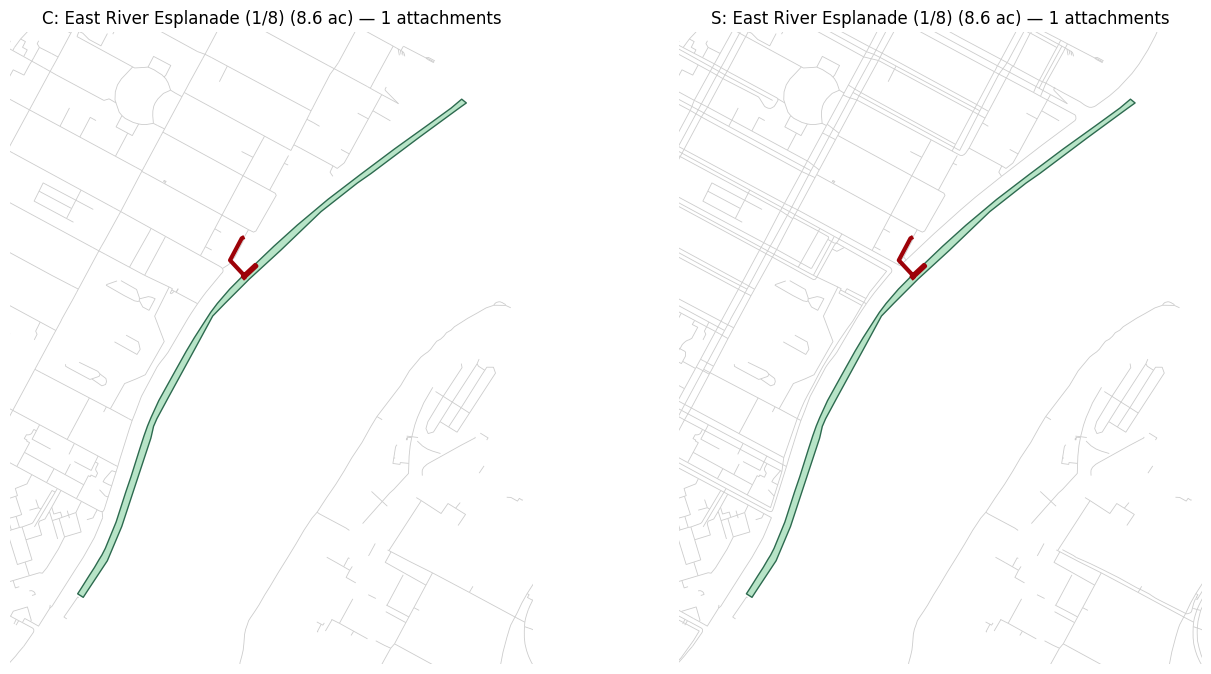

In [9]:
focus = parks[(parks.borough == AREA_BOROUGHS[0]) & parks.in_main].sort_values("acres").iloc[-40]
win = focus.geometry.buffer(120).envelope
fig, axes = plt.subplots(1, 2, figsize=(14, 7))
for ax, v in zip(axes, VARIANTS):
    segs = gpd.read_parquet(NET_DIR / f"segments_{v}.parquet", columns=["seg_id", "geometry"])
    segs = segs.iloc[segs.sindex.query(win, predicate="intersects")]
    a = dflt[(dflt.variant == v) & (dflt.park_id == focus.park_id)]
    gpd.GeoSeries([focus.geometry], crs=CRS).plot(ax=ax, color="#b7e4c7", edgecolor="#2d6a4f")
    segs.plot(ax=ax, color="#cccccc", linewidth=0.6)
    sa = segs[segs.seg_id.isin(a.seg_id)]
    sa.plot(ax=ax, color="#e76f51", linewidth=1.2)
    segs[segs.seg_id.isin(a.loc[a.fps_rank < K_SOURCES, "seg_id"])].plot(ax=ax, color="#9d0208", linewidth=3)
    ax.set_xlim(win.bounds[0], win.bounds[2]); ax.set_ylim(win.bounds[1], win.bounds[3])
    ax.set_title(f"{v}: {focus['name']} ({focus.acres:.1f} ac) — {len(a)} attachments")
    ax.set_axis_off()
plt.tight_layout()
plt.show()